In [1]:
import sys
import git
import pathlib

# Set up the PROJ_ROOT variable
PROJ_ROOT_PATH = pathlib.Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
PROJ_ROOT =  str(PROJ_ROOT_PATH)
if PROJ_ROOT not in sys.path:
    sys.path.append(PROJ_ROOT)

# Explicitly add the current notebook's directory
CURRENT_DIR = str(pathlib.Path().absolute())
if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

In [2]:
# https://lownoisefactory.com/product/lnf-nano9m/
# length = 460E-3 # 460 mm0
area = 0.0509E-6 # 30 AWG = 0.0509 mm2

# krinner
l_50K = 20E-2 
l_4K = 29E-2 
l_Still = 25E-2 
l_CP = 17E-2 
l_MXC = 14E-2 

# Thermal Conductivity

In [3]:
# https://www.lakeshore.com/products/categories/specification/temperature-products/cryogenic-accessories/cryogenic-wire
## Manganin - # 83-Cu, 13-Mn, 4-Ni
import numpy as np
x_temp = np.array([0.4, 1, 4, 10, 20, 80, 150, 300])
y_k = np.array([0.02, 0.06, 0.5, 2, 3.3, 13, 16, 22])

In [4]:
# Perform linear fit (degree 1 for a straight line)
coefficients = np.polyfit(x_temp, y_k, 2)
# slope = coefficients[0]
# intercept = coefficients[1]

In [5]:
# Generate predicted y values
# y_pred = coefficients[0]*x_temp**2 + coefficients[1]*x_temp**1 + coefficients[2]
y_pred = coefficients[0]*x_temp**2 + coefficients[1]*x_temp**1 + coefficients[2]*x_temp**0# + coefficients[3]
# y_pred = slope * x_temp + intercept

In [6]:
# conductivity, K
def conductivity(x_temp):
    # slope = 0.1628357541740877
    # intercept = 0.014792328051714288
    # k = slope*T + intercept
    y_pred = coefficients[0]*x_temp**2 + coefficients[1]*x_temp**1 + coefficients[2]*x_temp**0# + coefficients[3]
    return y_pred # W/(m.K)

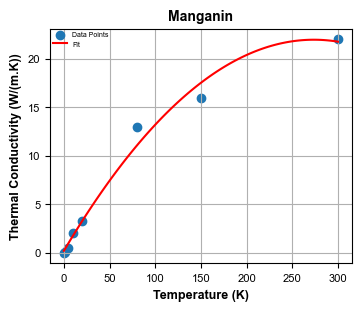

In [7]:
import matplotlib.pyplot as plt
from library.utils import fontstyle
title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

# IEEE TQE Guidelines
# Single column: 3.5" (wide) x 8.5" (height)
# Double column: 7.16" (wide) x 8.5" (height)
fig, ax = plt.subplots(nrows=1, 
                       ncols=1, 
                       figsize=(3.5, 3), 
                       constrained_layout=True)

# Plotting the results
x_vals = np.linspace(0,300,100)
y_vals = conductivity(x_vals)
ax.scatter(x_temp, y_k, label='Data Points')
ax.plot(x_vals, y_vals, color='red', label='Fit')
ax.set_title("Manganin", fontproperties=title_font)
ax.set_xlabel('Temperature (K)', fontproperties=axis_label_font)
ax.set_ylabel('Thermal Conductivity (W/(m.K))', fontproperties=axis_label_font)
for label in ax.get_yticklabels() :
        label.set_fontproperties(tick_label_font)

for label in ax.get_xticklabels() :
        label.set_fontproperties(tick_label_font)
    

ax.legend(prop=legend_font,
          frameon=False,
          borderaxespad=0.)

ax.grid(True)

plt.savefig(f"./mn_k.png",dpi=600)
plt.show()

In [8]:
from scipy.integrate import quad
import math

# Integrate f(x) from 50K to 4K
result, error = quad(conductivity, 4, 50)
print(f"The numerical result is {result:.6f} (+-{error:.10g})")

PHL_Mn_4K = result * (area/l_4K)
print(f"{PHL_Mn_4K=:.5e}")  # W/m

The numerical result is 195.054335 (+-2.165538136e-12)
PHL_Mn_4K=3.42354e-05


In [9]:
# Integrate f(x) from 300K to 50K
result, error = quad(conductivity, 50, 300)
print(f"The numerical result is {result:.6f} (+-{error:.10g})")

PHL_Mn_50K = result * (area/l_50K)
print(f"{PHL_Mn_50K=:.5e}")  # W/m

The numerical result is 4405.575110 (+-4.891170924e-11)
PHL_Mn_50K=1.12122e-03


# Electrical Resistivity

A key feature of Manganin is that its resistance changes very little with temperature even at cryogenic temperatures.

Hence we can model the resistivity from 4K to 50K using a linear fit using the values provided in https://www.lakeshore.com/products/categories/specification/temperature-products/cryogenic-accessories/cryogenic-wire

In [10]:
# https://www.lakeshore.com/products/categories/specification/temperature-products/cryogenic-accessories/cryogenic-wire
# Assuming 30 AWG
## Manganin - # 83-Cu, 13-Mn, 4-Ni
x_temp = np.array([4.2, 77, 305])
y_rho = np.array([8.64, 9.13, 9.69]) # Ohm/m for 30 AWG wire

In [11]:
coefficients = np.polyfit(x_temp, y_rho, 2)
y_pred = coefficients[0]*x_temp**2 + coefficients[1]*x_temp**1 + coefficients[2]*x_temp**0

def manganin_rho(x_temp):
    y_pred = coefficients[0]*x_temp**2 + coefficients[1]*x_temp**1 + coefficients[2]*x_temp**0
    return y_pred

In [12]:
# # Perform linear fit (degree 1 for a straight line)
# slope, intercept = np.polyfit(x_temp, y_rho, 1)

# # Linear Model for resistivity of Manganin
# def manganin_rho(T):
#     k = slope * T + intercept
#     return k # in 1e-8 ohm-meter

In [13]:
T_range = np.linspace(0, 310, 100)
rho_vals = manganin_rho(T_range) # Ohm/m for 30 AWG wire

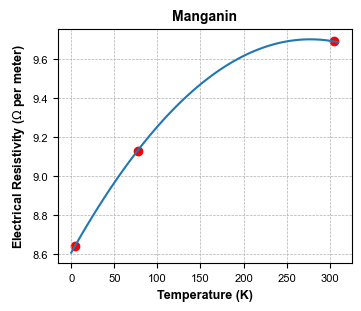

In [14]:
import matplotlib.pyplot as plt
from library.utils import fontstyle
title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

# IEEE TQE Guidelines
# Single column: 3.5" (wide) x 8.5" (height)
# Double column: 7.16" (wide) x 8.5" (height)
fig, ax = plt.subplots(nrows=1, 
                       ncols=1, 
                       figsize=(3.5, 3), 
                       constrained_layout=True)


# Similar to graph in (https://www.copper.org/resources/properties/cryogenic/)
ax.plot(T_range, rho_vals)
ax.scatter(x_temp, y_rho, color="red")
# ax.set_xscale("log")
# ax.set_yscale("log")
# --- enable both major and minor grid lines ---
ax.grid(True, which="both", linestyle="--", linewidth=0.5)

ax.set_title("Manganin", fontproperties=title_font)
ax.set_xlabel('Temperature (K)', fontproperties=axis_label_font)
ax.set_ylabel(r'Electrical Resistivity ($\Omega$ per meter)', fontproperties=axis_label_font)

for label in ax.get_yticklabels() :
        label.set_fontproperties(tick_label_font)

for label in ax.get_xticklabels() :
        label.set_fontproperties(tick_label_font)

plt.savefig(f"./mn_rho.png",dpi=600)
plt.show()

In [15]:
# Integrate and average
T_min, T_max = 4, 50
total_int, _ = quad(manganin_rho, T_min, T_max)
average_rho = total_int / (T_max - T_min) # Ohm/m for 30 AWG wire
print(f"Average Resistivity (4K-50K): {average_rho:.6e} Ohm-m")

R_Mn_4K = average_rho * l_4K
print(f"Average Resistance of {l_4K} m 30 AWG Mn wire between {T_max}K and {T_min}K is {R_Mn_4K=:.3e} ohms")

Average Resistivity (4K-50K): 8.807156e+00 Ohm-m
Average Resistance of 0.29 m 30 AWG Mn wire between 50K and 4K is R_Mn_4K=2.554e+00 ohms


In [16]:
# Integrate and average
T_min, T_max = 50, 300
total_int, _ = quad(manganin_rho, T_min, T_max)
average_rho = total_int / (T_max - T_min) # Ohm/m for 30 AWG wire
print(f"Average Resistivity (4K-50K): {average_rho:.6e} Ohm-m")

R_Mn_50K = average_rho * l_50K
print(f"Average Resistance of {l_50K} m 30 AWG Mn wire between {T_max}K and {T_min}K is {R_Mn_50K=:.3e} ohms")

Average Resistivity (4K-50K): 9.477733e+00 Ohm-m
Average Resistance of 0.2 m 30 AWG Mn wire between 300K and 50K is R_Mn_50K=1.896e+00 ohms
